# 1- Load and understanding data

In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 2- Cleaning data

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Drop unuseful columns

In [ ]:
df.drop(['Name'], axis=1, inplace=True)
df.drop(['PassengerId'], axis=1, inplace=True)
df.drop(['Ticket'], axis=1, inplace=True)
df.drop(['Cabin'], axis=1, inplace=True)

### age column has oultlier value so we use median not mean

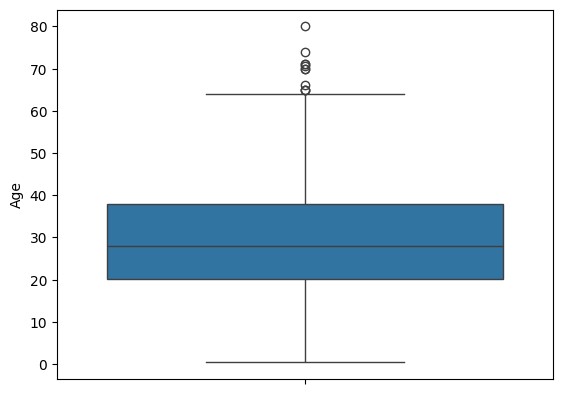

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(df['Age'])
plt.show()

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


# 3- Visulization to explore and Feature Selection


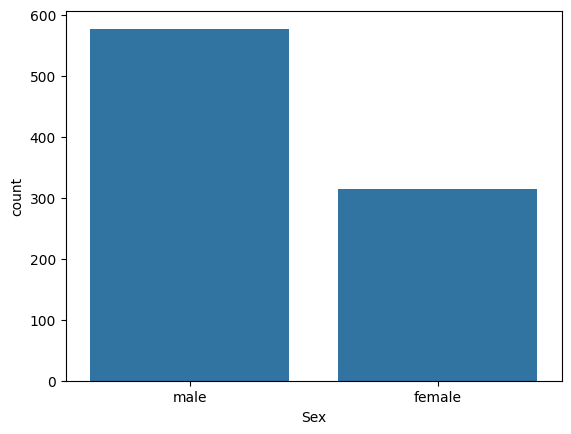

In [ ]:
sns.countplot(x=df['Sex'])
plt.show()

### male on titainc about 2x female

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

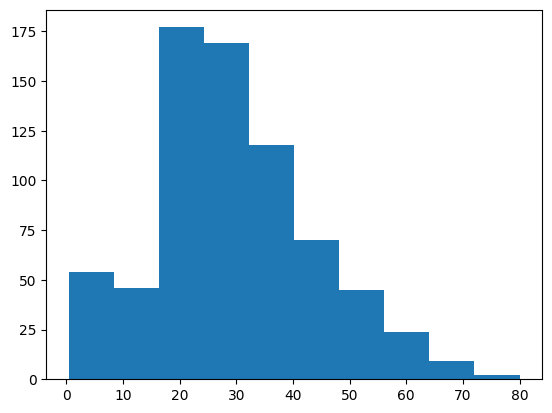

In [ ]:
plt.hist(df['Age'])  # outliers?????????????


### most age on titanic in range 20 - 50 years

In [ ]:
count_class = df['Pclass'].value_counts()
count_class

,count
Pclass,
3,491
1,216
2,184


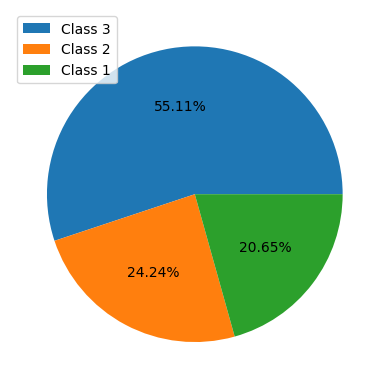

In [ ]:
plt.pie(count_class,autopct='%.2f%%')
plt.legend(['Class 3','Class 2','Class 1'])
plt.show()

# Features Selection
* Correlation >> Numerical columns
* Graphs >> Categories columns

In [ ]:
number_columns = df.select_dtypes(include='number')
number_columns.corr()

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500
Age,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566
SibSp,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000


-------------------------

### We will select the most influential features that have a significant impact on the model’s output

* Pclass
* Fare

In [ ]:
object_columns = df.select_dtypes(include='object').columns
object_columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

-----------------------

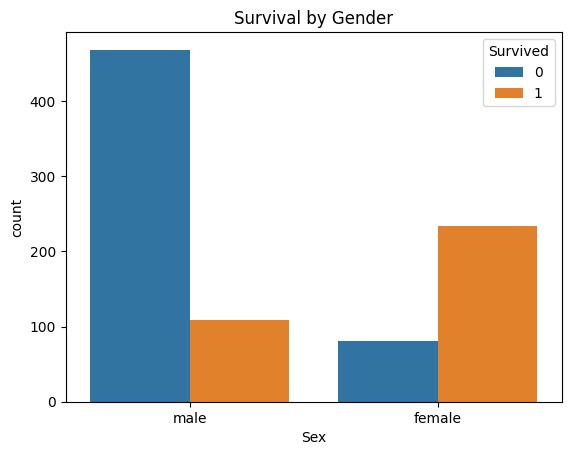

In [ ]:
import seaborn as sns
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title("Survival by Gender")
plt.show()

### Graph show that output will dependend on Gender

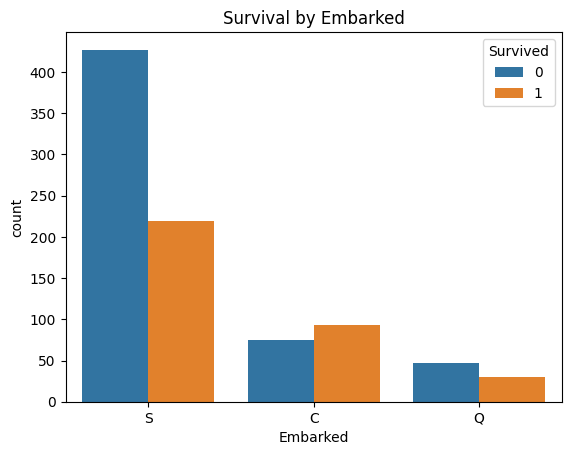

In [ ]:
import seaborn as sns
sns.countplot(data=df, x='Embarked', hue='Survived')
plt.title("Survival by Embarked")
plt.show()

------------------

In [ ]:
new_df = df[['Pclass','Fare','Sex','Embarked','Survived']]
new_df.head()

,Pclass,Fare,Sex,Embarked,Survived
0,3,7.2500,male,S,0
1,1,71.2833,female,C,1
2,3,7.9250,female,S,1
3,1,53.1000,female,S,1
4,3,8.0500,male,S,0


# 4- Modeling

### encoding
covert categrical data to numeric , model cann't trainning with categrical data

* one hot encoding
* label encoding

In [ ]:
#encoding map (label)
new_df['Sex'] = new_df['Sex'].map({'male':0, 'female':1})
new_df['Embarked'] = new_df['Embarked'].map({'S':0, 'C':1, 'Q':2})

#another method (one hot encoding)
#pd.get_dummies(df['Sex','Embarked'])


<ipython-input-56-badcb2038b23>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['Sex'] = new_df['Sex'].map({'male':0, 'female':1})
<ipython-input-56-badcb2038b23>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['Embarked'] = new_df['Embarked'].map({'S':0, 'C':1, 'Q':2})


In [ ]:
new_df.head()

,Pclass,Fare,Sex,Embarked,Survived
0,3,7.2500,0,0,0
1,1,71.2833,1,1,1
2,3,7.9250,1,0,1
3,1,53.1000,1,0,1
4,3,8.0500,0,0,0


### Sklearn libarary

In [ ]:
# libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
#split data
X = new_df.drop(['Survived'], axis=1)
y =  new_df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#build model and fit
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
#prediction
y_pred=model.predict(X_test)

In [ ]:
model.predict([[3	,7.2500,	0	,0]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
## evluation
accuracy_score(y_test, y_pred)

0.7821229050279329